# RFM Customer Segmentation

This notebook segments Olist customers based on their purchasing behavior using the RFM framework.

The main goals are:
- to calculate Recency, Frequency, and Monetary metrics;
- to assign RFM scores;
- to identify meaningful customer segments;
- to compare segment size and business value.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from etl.config import get_engine

engine = get_engine()

pd.set_option("display.max_columns", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}",
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

pd.read_sql(
    "SELECT current_database() AS database_name;",
    engine,
)

,database_name
0,olist_analytics


## 1. RFM Data Preparation

In [3]:
query = """
SELECT
    MAX(order_purchase_timestamp)::DATE + INTERVAL '1 day'
        AS analysis_date
FROM analytics.order_metrics
WHERE order_status = 'delivered';
"""

analysis_date = pd.read_sql(query, engine).loc[0, "analysis_date"]

analysis_date

Timestamp('2018-08-30 00:00:00')

In [ ]:
query = """
SELECT
    customer_unique_id,

    MAX(order_purchase_timestamp)::DATE
        AS last_purchase_date,

    COUNT(DISTINCT order_id)
        AS frequency,

    ROUND(
        SUM(order_items_value)::NUMERIC, 2
    ) AS monetary

FROM analytics.order_metrics

WHERE order_status = 'delivered'
  AND customer_unique_id IS NOT NULL
  AND order_items_value IS NOT NULL

GROUP BY customer_unique_id;
"""

rfm = pd.read_sql(query, engine)

rfm.head()

,customer_unique_id,last_purchase_date,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,1,196.89


In [ ]:
rfm["last_purchase_date"] = pd.to_datetime(
    rfm["last_purchase_date"]
)

analysis_date = pd.to_datetime(analysis_date)

rfm["recency"] = (
    analysis_date - rfm["last_purchase_date"]
).dt.days

In [6]:
rfm = rfm[
    [
        "customer_unique_id",
        "recency",
        "frequency",
        "monetary",
        "last_purchase_date",
    ]
]

rfm.head()

,customer_unique_id,recency,frequency,monetary,last_purchase_date
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,2018-05-10
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,2018-05-07
2,0000f46a3911fa3c0805444483337064,538,1,86.22,2017-03-10
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62,2017-10-12
4,0004aac84e0df4da2b147fca70cf8255,289,1,196.89,2017-11-14


In [7]:
rfm.shape

(93358, 5)

In [8]:
rfm.isna().sum()

customer_unique_id    0
recency               0
frequency             0
monetary              0
last_purchase_date    0
dtype: int64

In [9]:
rfm[
    [
        "recency",
        "frequency",
        "monetary",
    ]
].describe(
    percentiles=[
        0.25,
        0.5,
        0.75,
        0.9,
        0.95,
        0.99,
    ]
)

,recency,frequency,monetary
count,"93,358.00","93,358.00","93,358.00"
mean,238.48,1.03,165.17
std,152.60,0.21,226.29
min,1.00,1.00,9.59
25%,115.00,1.00,63.01
50%,219.00,1.00,107.78
75%,347.00,1.00,182.51
90%,466.00,1.00,317.99
95%,520.00,1.00,469.48
99%,576.00,2.00,"1,097.06"


## 2. RFM Metric Distributions

### Recency Distribution

In [10]:
rfm["recency"].describe(
    percentiles=[
        0.5,
        0.75,
        0.9,
        0.95,
        0.99,
    ]
)

count   93,358.00
mean       238.48
std        152.60
min          1.00
50%        219.00
75%        347.00
90%        466.00
95%        520.00
99%        576.00
max        714.00
Name: recency, dtype: float64

In [11]:
recency_99 = rfm["recency"].quantile(0.99)

recency_99

np.float64(576.0)

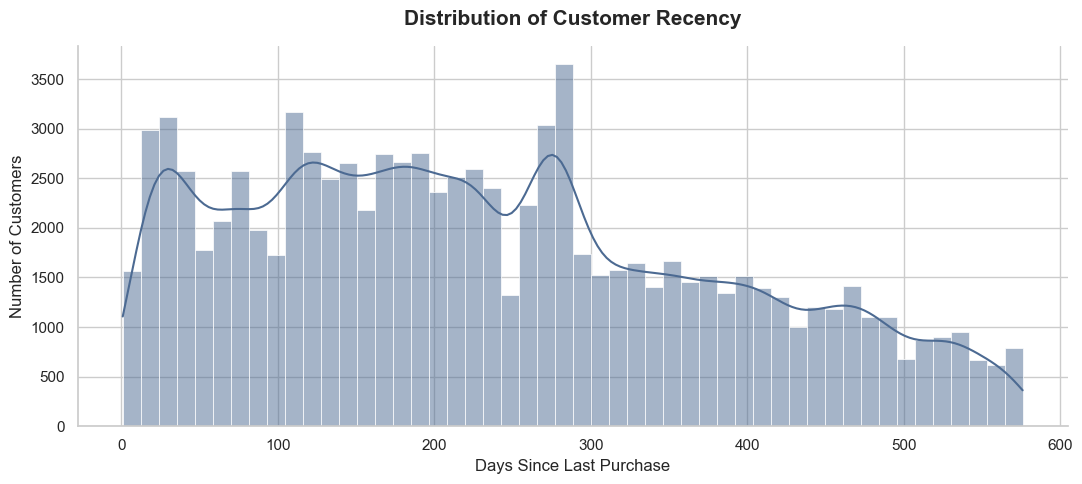

In [12]:
plot_data = rfm.loc[
    rfm["recency"] <= recency_99
].copy()

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(
    data=plot_data,
    x="recency",
    bins=50,
    kde=True,
    color="#4C6A92",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.set_title(
    "Distribution of Customer Recency",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Days Since Last Purchase")
ax.set_ylabel("Number of Customers")

sns.despine()
plt.tight_layout()
plt.show()

### Recency distribution findings

Customer recency is broadly distributed across the observation period.

A large share of customers made their most recent purchase within approximately the last 300 days, while the number of customers generally declines at higher recency values.

The distribution contains several local peaks rather than one smooth concentration. This is consistent with changes in customer acquisition volume over time and with the fact that most customers made only one purchase.

Customers with low recency are more recent and potentially more responsive to re-engagement campaigns, while customers with high recency have been inactive for a long time and may require stronger incentives to return.

### Frequency Distribution

In [13]:
frequency_distribution = (
    rfm
    .groupby("frequency")
    .agg(
        customers_count=(
            "customer_unique_id",
            "count",
        )
    )
    .reset_index()
    .sort_values("frequency")
)

frequency_distribution["customers_share_percent"] = (
    frequency_distribution["customers_count"]
    / frequency_distribution["customers_count"].sum()
    * 100
)

frequency_distribution

,frequency,customers_count,customers_share_percent
0,1,90557,97.00
1,2,2573,2.76
2,3,181,0.19
3,4,28,0.03
4,5,9,0.01
5,6,5,0.01
6,7,3,0.00
7,9,1,0.00
8,15,1,0.00


In [15]:
rfm["frequency_group"] = pd.cut(
    rfm["frequency"],
    bins=[0, 1, 2, 3, 4, float("inf")],
    labels=[
        "1 order",
        "2 orders",
        "3 orders",
        "4 orders",
        "5+ orders",
    ],
)

frequency_group_distribution = (
    rfm
    .groupby(
        "frequency_group",
        observed=False,
    )
    .agg(
        customers_count=(
            "customer_unique_id",
            "count",
        )
    )
    .reset_index()
)

frequency_group_distribution["customers_share_percent"] = (
    frequency_group_distribution["customers_count"]
    / frequency_group_distribution["customers_count"].sum()
    * 100
)

frequency_group_distribution

,frequency_group,customers_count,customers_share_percent
0,1 order,90557,97.00
1,2 orders,2573,2.76
2,3 orders,181,0.19
3,4 orders,28,0.03
4,5+ orders,19,0.02


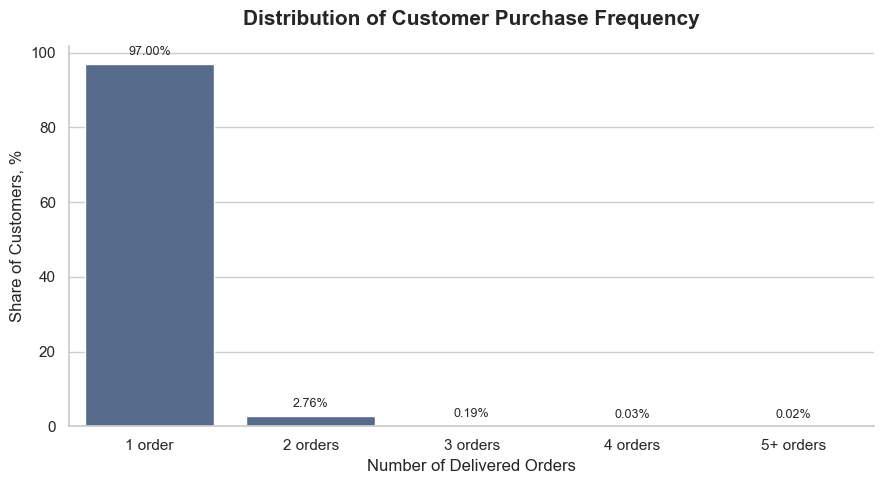

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=frequency_group_distribution,
    x="frequency_group",
    y="customers_share_percent",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Distribution of Customer Purchase Frequency",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Number of Delivered Orders")
ax.set_ylabel("Share of Customers, %")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Frequency distribution findings

Purchase frequency is extremely concentrated among one-time customers.

Approximately 97% of customers made only one delivered order. Around 2.76% made two orders, while customers with three or more orders represent only a negligible share of the customer base.

This confirms that customer behavior is dominated by single purchases and that the `Frequency` metric has very low variability. As a result, frequency-based segmentation will be less informative than recency and monetary value unless repeat customers are handled carefully.

### Monetary Distribution

In [17]:
rfm["monetary"].describe(
    percentiles=[
        0.5,
        0.75,
        0.9,
        0.95,
        0.99,
    ]
)

count   93,358.00
mean       165.17
std        226.29
min          9.59
50%        107.78
75%        182.51
90%        317.99
95%        469.48
99%      1,097.06
max     13,664.08
Name: monetary, dtype: float64

In [18]:
monetary_99 = rfm["monetary"].quantile(0.99)

monetary_99

np.float64(1097.0616999999986)

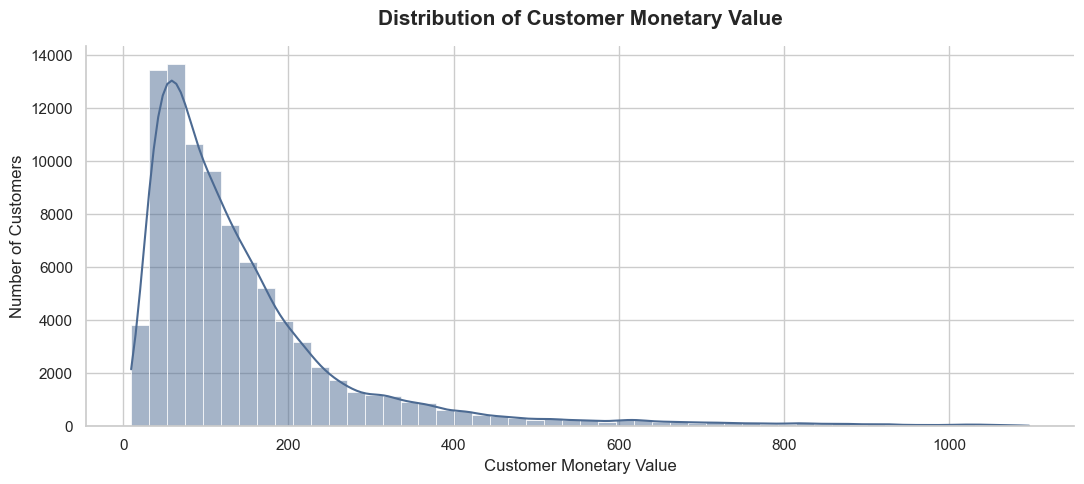

In [19]:
plot_data = rfm.loc[
    rfm["monetary"] <= monetary_99
].copy()

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(
    data=plot_data,
    x="monetary",
    bins=50,
    kde=True,
    color="#4C6A92",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.set_title(
    "Distribution of Customer Monetary Value",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Customer Monetary Value")
ax.set_ylabel("Number of Customers")

sns.despine()
plt.tight_layout()
plt.show()

### Monetary distribution findings

Customer monetary value is strongly right-skewed.

Most customers generated relatively low total value, while a small group of high-value customers forms a long right tail. This means that the average monetary value is likely higher than the median and is sensitive to a small number of expensive customers.

The values above the 99th percentile were excluded only from the visualization. They should remain in the RFM dataset because high-value customers are particularly important for segmentation.

## 3. RFM Scoring

In [20]:
rfm["r_score"] = pd.qcut(
    rfm["recency"],
    q=4,
    labels=[4, 3, 2, 1],
).astype(int)

In [21]:
rfm["f_score"] = pd.cut(
    rfm["frequency"],
    bins=[0, 1, 2, 3, float("inf")],
    labels=[1, 2, 3, 4],
).astype(int)

In [22]:
rfm["m_score"] = pd.qcut(
    rfm["monetary"],
    q=4,
    labels=[1, 2, 3, 4],
).astype(int)

In [23]:
rfm["rfm_code"] = (
    rfm["r_score"].astype(str)
    + rfm["f_score"].astype(str)
    + rfm["m_score"].astype(str)
)

rfm["rfm_total_score"] = (
    rfm["r_score"]
    + rfm["f_score"]
    + rfm["m_score"]
)

rfm.head()

,customer_unique_id,recency,frequency,monetary,last_purchase_date,frequency_group,r_score,f_score,m_score,rfm_code,rfm_total_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,2018-05-10,1 order,4,1,3,413,8
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,2018-05-07,1 order,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,538,1,86.22,2017-03-10,1 order,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62,2017-10-12,1 order,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,289,1,196.89,2017-11-14,1 order,2,1,4,214,7


In [24]:
rfm[
    [
        "r_score",
        "f_score",
        "m_score",
        "rfm_total_score",
    ]
].describe()

,r_score,f_score,m_score,rfm_total_score
count,"93,358.00","93,358.00","93,358.00","93,358.00"
mean,2.50,1.03,2.50,6.04
std,1.12,0.20,1.12,1.63
min,1.00,1.00,1.00,3.00
25%,2.00,1.00,1.00,5.00
50%,3.00,1.00,2.00,6.00
75%,4.00,1.00,3.00,7.00
max,4.00,4.00,4.00,12.00


In [25]:
rfm_score_distribution = (
    rfm
    .groupby("rfm_total_score")
    .agg(
        customers_count=(
            "customer_unique_id",
            "count",
        )
    )
    .reset_index()
    .sort_values("rfm_total_score")
)

rfm_score_distribution["customers_share_percent"] = (
    rfm_score_distribution["customers_count"]
    / rfm_score_distribution["customers_count"].sum()
    * 100
)

rfm_score_distribution

,rfm_total_score,customers_count,customers_share_percent
0,3,5963,6.39
1,4,11761,12.60
2,5,17208,18.43
3,6,22567,24.17
4,7,17203,18.43
5,8,11904,12.75
6,9,6160,6.60
7,10,510,0.55
8,11,60,0.06
9,12,22,0.02


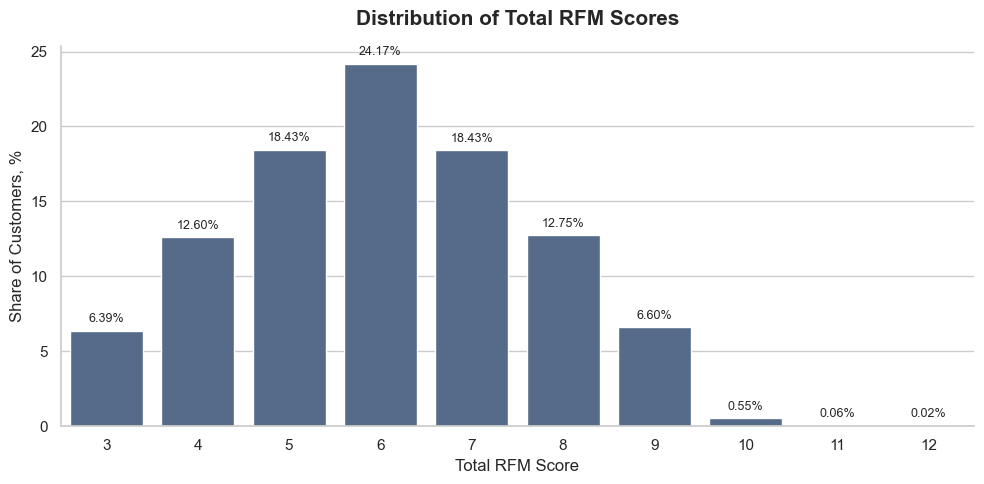

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=rfm_score_distribution,
    x="rfm_total_score",
    y="customers_share_percent",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Distribution of Total RFM Scores",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Total RFM Score")
ax.set_ylabel("Share of Customers, %")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### RFM score findings

The total RFM score is concentrated in the middle of the scale.

The most common score is 6, which includes approximately 24% of customers. Scores 5 and 7 are also frequent, while very high scores are extremely rare.

This pattern is largely explained by the low variability of the `Frequency` metric: most customers receive the minimum frequency score because they placed only one order. As a result, high total RFM scores are available only to a very small group of recent, repeat, and high-value customers.

Therefore, the total score is useful as a summary indicator, but meaningful business interpretation requires explicit customer segments based on the individual R, F, and M components.

## 4. Customer Segments

In [27]:
def assign_rfm_segment(row):
    if (
        row["r_score"] == 4
        and row["f_score"] >= 3
        and row["m_score"] >= 3
    ):
        return "Champions"

    if (
        row["r_score"] >= 3
        and row["f_score"] >= 2
        and row["m_score"] >= 2
    ):
        return "Loyal Customers"

    if (
        row["r_score"] == 4
        and row["f_score"] == 1
    ):
        return "New Customers"

    if (
        row["r_score"] >= 3
        and row["m_score"] >= 3
    ):
        return "High-Value Recent"

    if (
        row["r_score"] <= 2
        and row["f_score"] >= 2
    ):
        return "At Risk"

    if (
        row["r_score"] == 1
        and row["f_score"] == 1
    ):
        return "Lost Customers"

    return "Regular Customers"

In [28]:
rfm["segment"] = rfm.apply(
    assign_rfm_segment,
    axis=1,
)

rfm[
    [
        "customer_unique_id",
        "recency",
        "frequency",
        "monetary",
        "r_score",
        "f_score",
        "m_score",
        "segment",
    ]
].head()

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,New Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,New Customers
2,0000f46a3911fa3c0805444483337064,538,1,86.22,1,1,2,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62,2,1,1,Regular Customers
4,0004aac84e0df4da2b147fca70cf8255,289,1,196.89,2,1,4,Regular Customers


In [29]:
segment_summary = (
    rfm
    .groupby("segment")
    .agg(
        customers_count=(
            "customer_unique_id",
            "count",
        ),
        average_recency=(
            "recency",
            "mean",
        ),
        average_frequency=(
            "frequency",
            "mean",
        ),
        average_monetary=(
            "monetary",
            "mean",
        ),
        total_monetary=(
            "monetary",
            "sum",
        ),
    )
    .reset_index()
)

In [30]:
segment_summary["customers_share_percent"] = (
    segment_summary["customers_count"]
    / segment_summary["customers_count"].sum()
    * 100
)

segment_summary["monetary_share_percent"] = (
    segment_summary["total_monetary"]
    / segment_summary["total_monetary"].sum()
    * 100
)

segment_summary = segment_summary.sort_values(
    "customers_count",
    ascending=False,
)

segment_summary

,segment,customers_count,average_recency,average_frequency,average_monetary,total_monetary,customers_share_percent,monetary_share_percent
6,Regular Customers,34042,241.05,1.00,126.82,"4,317,104.22",36.46,28.00
5,New Customers,22760,58.41,1.00,164.53,"3,744,600.72",24.38,24.28
3,Lost Customers,22692,452.53,1.00,160.94,"3,652,064.58",24.31,23.68
2,High-Value Recent,11088,166.34,1.00,256.41,"2,843,060.36",11.88,18.44
4,Loyal Customers,1443,115.93,2.07,303.20,"437,518.04",1.55,2.84
0,At Risk,1258,352.97,2.08,300.79,"378,395.15",1.35,2.45
1,Champions,75,58.29,3.61,627.08,"47,030.68",0.08,0.31


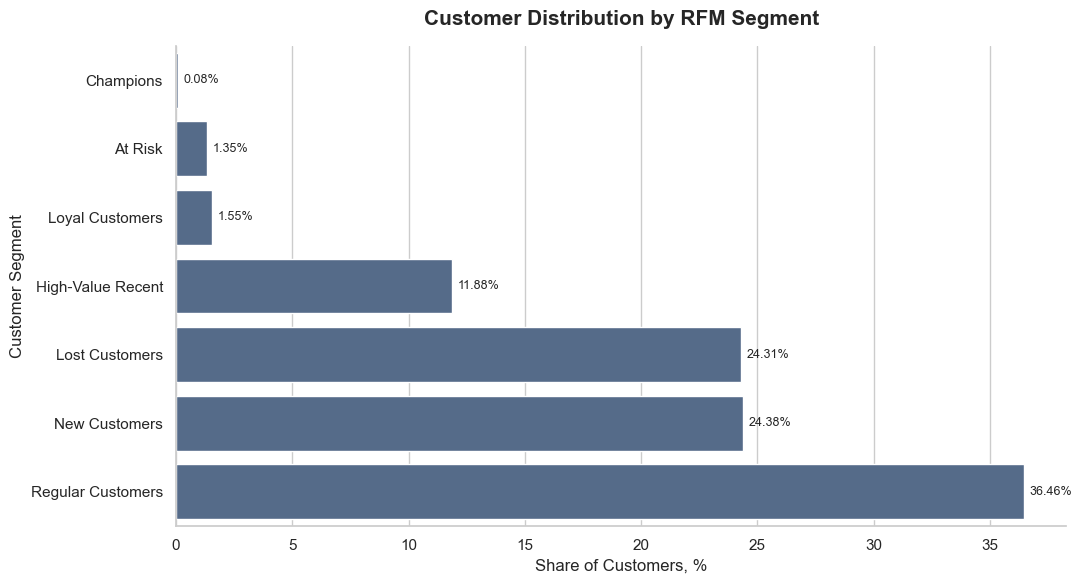

In [31]:
plot_data = (
    segment_summary
    .sort_values(
        "customers_share_percent",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="customers_share_percent",
    y="segment",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Customer Distribution by RFM Segment",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Share of Customers, %")
ax.set_ylabel("Customer Segment")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Customer segment findings

The customer base is dominated by broad, low-frequency segments.

`Regular Customers` form the largest group at approximately 36.5% of customers. `New Customers` and `Lost Customers` each account for roughly one quarter of the customer base, which reflects both strong customer acquisition and weak repeat purchase behavior.

`High-Value Recent` customers represent around 11.9% of customers. This group is especially important because these customers purchased recently and generated relatively high monetary value, even though many of them may have made only one order.

`Loyal Customers`, `At Risk`, and especially `Champions` are very small segments. This is consistent with the earlier finding that repeated purchasing is rare across the platform.

Overall, the segmentation suggests that the main business opportunity is to convert recent and high-value one-time buyers into repeat customers.

## 5. Segment Comparison

In [32]:
segment_value_comparison = (
    segment_summary[
        [
            "segment",
            "customers_share_percent",
            "monetary_share_percent",
            "average_recency",
            "average_frequency",
            "average_monetary",
        ]
    ]
    .sort_values(
        "monetary_share_percent",
        ascending=False,
    )
)

segment_value_comparison

,segment,customers_share_percent,monetary_share_percent,average_recency,average_frequency,average_monetary
6,Regular Customers,36.46,28.00,241.05,1.00,126.82
5,New Customers,24.38,24.28,58.41,1.00,164.53
3,Lost Customers,24.31,23.68,452.53,1.00,160.94
2,High-Value Recent,11.88,18.44,166.34,1.00,256.41
4,Loyal Customers,1.55,2.84,115.93,2.07,303.20
0,At Risk,1.35,2.45,352.97,2.08,300.79
1,Champions,0.08,0.31,58.29,3.61,627.08


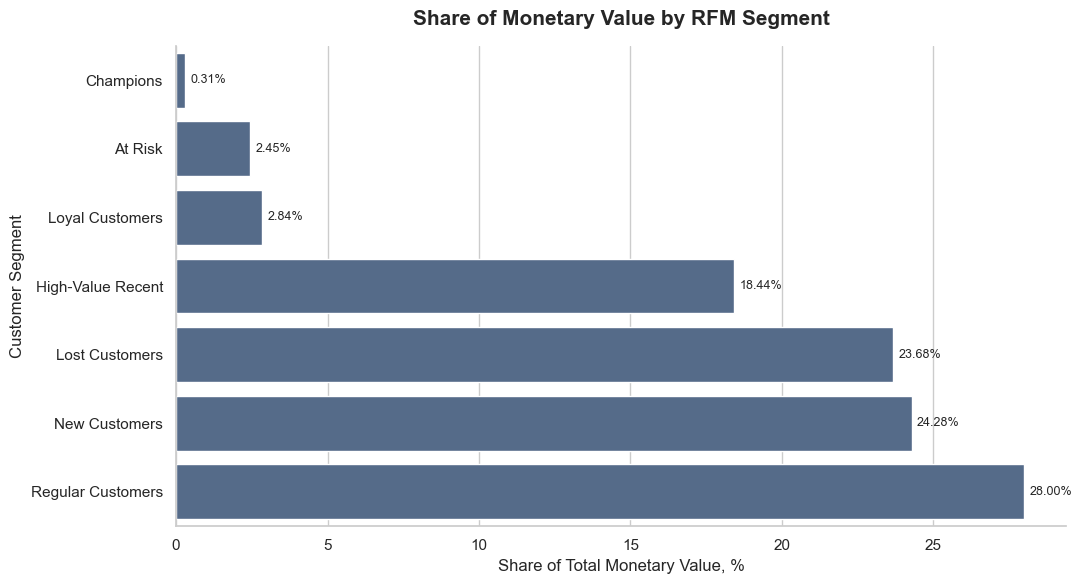

In [33]:
plot_data = (
    segment_summary
    .sort_values(
        "monetary_share_percent",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="monetary_share_percent",
    y="segment",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Share of Monetary Value by RFM Segment",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Share of Total Monetary Value, %")
ax.set_ylabel("Customer Segment")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Segment value findings

The distribution of monetary value differs from the distribution of customer counts.

`Regular Customers` remain the largest segment by total monetary value, contributing approximately 28% of the total. `New Customers` and `Lost Customers` each account for roughly one quarter of monetary value.

`High-Value Recent` customers represent only about 11.9% of customers but generate approximately 18.4% of total monetary value. This means that their average monetary value is substantially higher than that of most other segments.

`Champions`, `Loyal Customers`, and `At Risk` customers contribute relatively little to total monetary value because these segments are very small.

The most promising segment for targeted retention activity is therefore `High-Value Recent`: these customers have already demonstrated strong spending potential, but many have not yet become repeat buyers.

## 6. Key Findings

### Overall RFM segmentation findings

1. Customer behavior is strongly dominated by one-time purchases: approximately 97% of customers placed only one delivered order.

2. Recency varies substantially across the customer base, while Frequency has very low variability.

3. Monetary value is strongly right-skewed, with a small group of customers generating disproportionately high value.

4. Most customers are concentrated in the `Regular Customers`, `New Customers`, and `Lost Customers` segments.

5. `High-Value Recent` customers are especially important: they represent a relatively small share of customers but contribute a much larger share of monetary value.

6. `Champions` and `Loyal Customers` are rare, confirming that repeated purchasing is weak.

7. The main business opportunity is to convert recent and high-value one-time customers into repeat buyers.

### Business actions by segment

- `New Customers`: encourage a second purchase through onboarding, recommendations, and follow-up offers.
- `High-Value Recent`: prioritize personalized retention campaigns and premium recommendations.
- `Regular Customers`: use category-based recommendations and cross-selling to increase value.
- `At Risk`: send reactivation offers before customers become fully inactive.
- `Lost Customers`: use selective win-back campaigns rather than broad discounts.
- `Loyal Customers` and `Champions`: protect these customers with loyalty benefits and personalized service.

In [34]:
engine.dispose()